# Euclidean VAE

In [64]:
import os
import sys

mvae_dir = os.path.split(os.getcwd())[0]
if mvae_dir not in sys.path:
    sys.path.append(mvae_dir)

In [65]:
%pwd
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Imports

In [66]:
import torch
import numpy as np
import torch.optim as optim

import lib.dataloaders.synthetic_loader as dataloader
import lib.models.vae.euclidean_vae as model
import lib.trainer as trainer
import lib.utils as utils

from types import SimpleNamespace


### Set up and initialize data loader

In [67]:
# Set random seed for reproducibility
torch.manual_seed(59)
np.random.seed(49)

### Dataloader

In [79]:
loader_config = {
    "dataset_name": "s1_synthetic",
    "batch_size": 64,
    "rotation": "random",
    "n_times": 10000,
    "radius": 1.0,
    "major_radius": 4.0,
    "minor_radius": 1.0,
    #"radius_inner": 2.5,
    #"radius_outer": 3,
    "n_wiggles": 4,
    "geodesic_distortion_amp": 0.1,
    "embedding_dim": 3,
    "noise_var": 0.00001,
    "geodesic_distortion_func": "wiggles",
    "plot_dataset": True}

model_config = {
    'model_type': 'EuclideanVAE',
    'data_dim': loader_config["embedding_dim"],
    'latent_dim': 15,
    'sftbeta': 4.5,
    'device': "cpu",
    'encoder_widths': [100, 32, 32],
    'decoder_widths': [100, 32, 32]}

optimizer_config = {
    "learning_rate": 0.001,
}

trainer_config = {
    'num_epochs': 2,
    'log_interval': 100,
    'recon_loss': "MSE",
    'topo_loss': False,
    'alpha': 1,  # Weight for reconstruction loss
    'beta': 0,  # Weight for KL loss
    'gamma': 1,  # Weight for topological loss
}

curvature_config = {
    "n_grid_points": 1000,  # to compute curvature
}

config_dict = {}
config_dict.update(loader_config)
config_dict.update(model_config)
config_dict.update(optimizer_config)
config_dict.update(trainer_config)
config_dict.update(curvature_config)

config = SimpleNamespace(**config_dict)


### Dataloader

In [69]:
dataloader = dataloader.load_synthetic_ds(config)
train_loader, test_loader = dataloader

# from torch.utils.data import DataLoader
# from torch_topological.datasets import Spheres
# import torch
# 
# n_spheres = 10
# 
# # Train set
# data_set = Spheres(n_spheres=n_spheres)
# data_set = [(x[0].double(), x[1]) for x in data_set]
# 
# train_loader = DataLoader(
#     data_set,
#     batch_size=32,
#     shuffle=True,
#     drop_last=True
# )
# 
# # Test set
# data_set = Spheres(
#     train=False,
#     n_samples=2000,
#     n_spheres=n_spheres,
# )
# data_set = [(x[0].double(), x[1]) for x in data_set]
# 
# test_loader = DataLoader(
#     data_set,
#     shuffle=False,
#     batch_size=len(data_set)
# )
# 
# dataloader = train_loader, test_loader

### Model

In [70]:
model = model.EuclideanVAE(config)

### Optimizer

In [71]:
optimizer = optim.Adam(model.parameters(), lr=config.learning_rate)

### Train and evaluate model

In [72]:
history = trainer.MVAETrainer(model, dataloader, optimizer, config).train()

Trainer successfully initialized.
Training the gaussianVAE model.
Starting epoch 1/2
Epoch [1/2], Step [100/141], Loss: 27.2439
Epoch 1/2, Train Loss: 0.6915, Test Loss: 0.0172
--------------------------------------------------
Starting epoch 2/2
Epoch [2/2], Step [100/141], Loss: 0.0554
Epoch 2/2, Train Loss: 0.0027, Test Loss: 0.0006
--------------------------------------------------


### Plot history

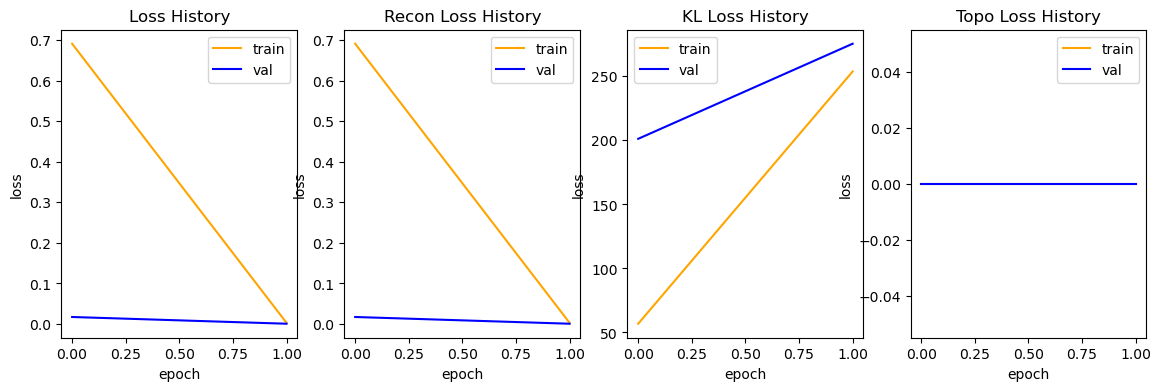

In [73]:
utils.show_training_history(history)

### Visualizing the latent space

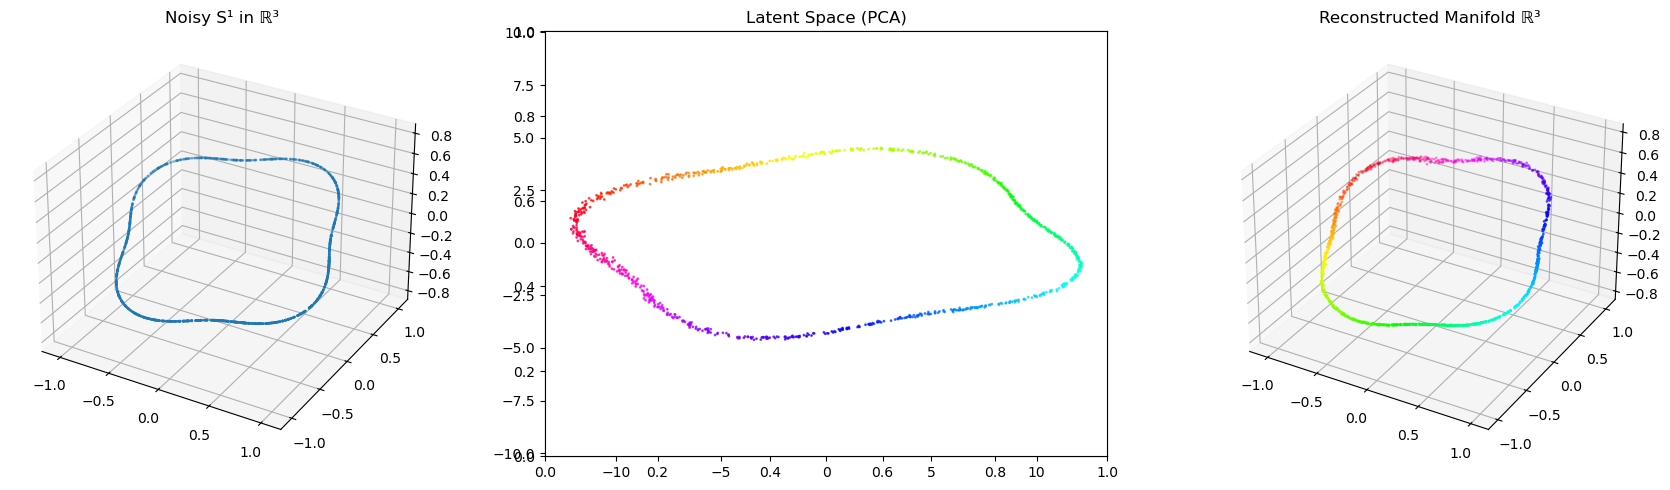

In [74]:
utils.plot_data_latents_recon(model, test_loader, "cpu", 6000)

### Plot reconstructed manifold

### Compute curvature error

In [75]:
utils.curvature_compute_plot_euclidean(config=config, model=model)

Computing learned curvature...
Forwarding data through model...
Starting actual computation...
An error occurred for i=5: linalg.inv: The diagonal element 15 is zero, the inversion could not be completed because the input matrix is singular.
tensor([[ 1.6340e-03,  2.9276e-04,  2.4388e-03,  4.8023e-04, -1.3128e-03,
          7.3084e-05,  1.5657e-04, -2.3339e-03, -1.1559e-03,  7.9010e-04,
          2.6397e-05,  2.3544e-03, -4.7515e-03, -2.2361e-03, -3.0258e-03],
        [ 2.9276e-04,  2.8740e-03,  3.9829e-03, -1.5730e-03,  8.0543e-04,
          1.4766e-03,  1.2227e-04, -2.3713e-03, -9.6762e-06,  3.9058e-04,
         -3.0998e-03,  3.1670e-03, -7.1610e-03, -1.8859e-03, -1.5685e-03],
        [ 2.4388e-03,  3.9829e-03,  8.1456e-03, -1.3833e-03, -6.6668e-04,
          1.9355e-03,  3.2448e-04, -6.0086e-03, -1.5114e-03,  1.4750e-03,
         -3.9106e-03,  7.0155e-03, -1.5114e-02, -5.2220e-03, -5.8651e-03],
        [ 4.8023e-04, -1.5730e-03, -1.3833e-03,  1.1213e-03, -9.9314e-04,
         -8.351

KeyboardInterrupt: 

Forwarding data through model...
Computing true curvature on latent vectors...
Starting actual computation...
Curvature computation finished.


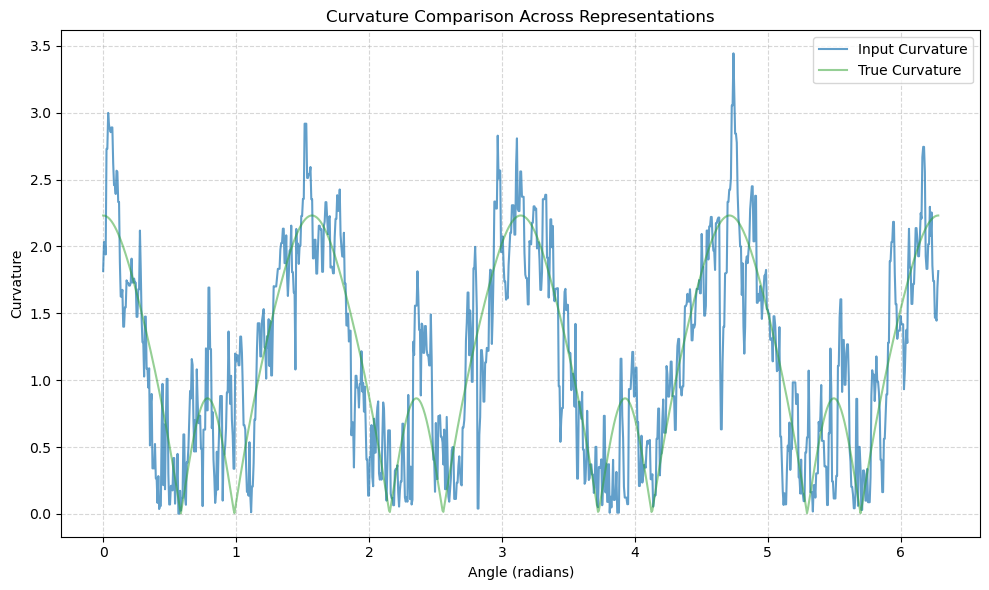

In [80]:
utils.plot_empiric_curvature(config=config, model=model)